# Biblioteki


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import ConfusionMatrixDisplay, roc_auc_score, classification_report, precision_recall_curve, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import PowerTransformer

# Wczytywanie danych

In [2]:
df_train = pd.read_csv('bankructwa.csv')
df_test = pd.read_csv('bankructwa_test.csv')

# Praca na danych


### Dane treningowe


In [3]:
df_train.head()

,Attr1,Attr2,Attr3,Attr4,Attr5,Attr6,Attr7,Attr8,Attr9,Attr10,...,Attr56,Attr57,Attr58,Attr59,Attr60,Attr61,Attr62,Attr63,Attr64,class
0,-0.271410,0.13465,0.865350,7.4267,15.6760,-2.54280,-0.271410,6.42670,2.3765,0.86535,...,-0.114210,-0.31364,1.11420,0.000000,3.1685,19.4650,20.680,17.6500,NaN,b'0'
1,0.083658,0.27709,0.409460,3.0260,45.4260,0.19399,0.106700,2.60890,1.6545,0.72291,...,0.079741,0.11572,0.93607,0.103730,7.4463,5.6539,44.586,8.1864,4.2593,b'0'
2,0.236420,0.56402,0.026152,1.0572,-19.1000,0.69381,0.236420,0.75955,1.2612,0.42840,...,0.207130,0.55185,0.79287,0.249650,18.3530,3.0653,134.130,2.7213,2.4069,b'0'
3,0.058190,0.75058,0.249420,1.3323,-5.2677,0.00000,0.070659,0.33230,1.6378,0.24942,...,0.014315,0.23330,0.95867,0.000000,5.9986,3.4660,167.270,2.1821,NaN,b'0'
4,0.133930,0.58257,0.000838,1.0015,-24.2360,0.26320,0.140630,0.71391,1.0514,0.41591,...,0.048904,0.32203,0.95110,0.035163,16.1000,7.8019,69.910,5.2210,6.8765,b'0'


In [4]:
class_mapping = {"b'0'": 0, "b'1'": 1}

df_train['class'] = df_train['class'].map(class_mapping)

In [5]:
df_train.head()

,Attr1,Attr2,Attr3,Attr4,Attr5,Attr6,Attr7,Attr8,Attr9,Attr10,...,Attr56,Attr57,Attr58,Attr59,Attr60,Attr61,Attr62,Attr63,Attr64,class
0,-0.271410,0.13465,0.865350,7.4267,15.6760,-2.54280,-0.271410,6.42670,2.3765,0.86535,...,-0.114210,-0.31364,1.11420,0.000000,3.1685,19.4650,20.680,17.6500,NaN,0
1,0.083658,0.27709,0.409460,3.0260,45.4260,0.19399,0.106700,2.60890,1.6545,0.72291,...,0.079741,0.11572,0.93607,0.103730,7.4463,5.6539,44.586,8.1864,4.2593,0
2,0.236420,0.56402,0.026152,1.0572,-19.1000,0.69381,0.236420,0.75955,1.2612,0.42840,...,0.207130,0.55185,0.79287,0.249650,18.3530,3.0653,134.130,2.7213,2.4069,0
3,0.058190,0.75058,0.249420,1.3323,-5.2677,0.00000,0.070659,0.33230,1.6378,0.24942,...,0.014315,0.23330,0.95867,0.000000,5.9986,3.4660,167.270,2.1821,NaN,0
4,0.133930,0.58257,0.000838,1.0015,-24.2360,0.26320,0.140630,0.71391,1.0514,0.41591,...,0.048904,0.32203,0.95110,0.035163,16.1000,7.8019,69.910,5.2210,6.8765,0


In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8792 entries, 0 to 8791
Data columns (total 65 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Attr1   8791 non-null   float64
 1   Attr2   8791 non-null   float64
 2   Attr3   8791 non-null   float64
 3   Attr4   8751 non-null   float64
 4   Attr5   8774 non-null   float64
 5   Attr6   8791 non-null   float64
 6   Attr7   8791 non-null   float64
 7   Attr8   8774 non-null   float64
 8   Attr9   8792 non-null   float64
 9   Attr10  8791 non-null   float64
 10  Attr11  8791 non-null   float64
 11  Attr12  8751 non-null   float64
 12  Attr13  8773 non-null   float64
 13  Attr14  8791 non-null   float64
 14  Attr15  8784 non-null   float64
 15  Attr16  8774 non-null   float64
 16  Attr17  8774 non-null   float64
 17  Attr18  8791 non-null   float64
 18  Attr19  8773 non-null   float64
 19  Attr20  8773 non-null   float64
 20  Attr21  8646 non-null   float64
 21  Attr22  8791 non-null   float64
 22  

In [7]:
missing_percentages = df_train.isna().mean() * 100

In [8]:

missing_percentages[missing_percentages > 30]

Attr37    45.541401
dtype: float64

In [9]:
df_train = df_train.drop('Attr37', axis = 'columns')

In [10]:
missing_percentages = df_train.isna().mean() * 100

In [11]:
col_missing = []

for col_name, percent in missing_percentages.items():
    if percent > 0:
        col_missing.append(col_name)


In [12]:
col_missing

['Attr1',
 'Attr2',
 'Attr3',
 'Attr4',
 'Attr5',
 'Attr6',
 'Attr7',
 'Attr8',
 'Attr10',
 'Attr11',
 'Attr12',
 'Attr13',
 'Attr14',
 'Attr15',
 'Attr16',
 'Attr17',
 'Attr18',
 'Attr19',
 'Attr20',
 'Attr21',
 'Attr22',
 'Attr23',
 'Attr24',
 'Attr25',
 'Attr26',
 'Attr27',
 'Attr28',
 'Attr29',
 'Attr30',
 'Attr31',
 'Attr32',
 'Attr33',
 'Attr34',
 'Attr35',
 'Attr36',
 'Attr38',
 'Attr39',
 'Attr40',
 'Attr41',
 'Attr42',
 'Attr43',
 'Attr44',
 'Attr45',
 'Attr46',
 'Attr47',
 'Attr48',
 'Attr49',
 'Attr50',
 'Attr51',
 'Attr52',
 'Attr53',
 'Attr54',
 'Attr56',
 'Attr57',
 'Attr58',
 'Attr59',
 'Attr60',
 'Attr61',
 'Attr62',
 'Attr63',
 'Attr64']

In [13]:
df_train[col_missing] = df_train[col_missing].fillna(df_train[col_missing].median())

In [14]:

missing_val = df_train[df_train.isna().any(axis=1)]
print(missing_val)

Empty DataFrame
Columns: [Attr1, Attr2, Attr3, Attr4, Attr5, Attr6, Attr7, Attr8, Attr9, Attr10, Attr11, Attr12, Attr13, Attr14, Attr15, Attr16, Attr17, Attr18, Attr19, Attr20, Attr21, Attr22, Attr23, Attr24, Attr25, Attr26, Attr27, Attr28, Attr29, Attr30, Attr31, Attr32, Attr33, Attr34, Attr35, Attr36, Attr38, Attr39, Attr40, Attr41, Attr42, Attr43, Attr44, Attr45, Attr46, Attr47, Attr48, Attr49, Attr50, Attr51, Attr52, Attr53, Attr54, Attr55, Attr56, Attr57, Attr58, Attr59, Attr60, Attr61, Attr62, Attr63, Attr64, class]
Index: []

[0 rows x 64 columns]


### Dane testowe


In [15]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 64 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Attr1   1000 non-null   float64
 1   Attr2   1000 non-null   float64
 2   Attr3   1000 non-null   float64
 3   Attr4   998 non-null    float64
 4   Attr5   997 non-null    float64
 5   Attr6   1000 non-null   float64
 6   Attr7   1000 non-null   float64
 7   Attr8   999 non-null    float64
 8   Attr9   1000 non-null   float64
 9   Attr10  1000 non-null   float64
 10  Attr11  1000 non-null   float64
 11  Attr12  998 non-null    float64
 12  Attr13  998 non-null    float64
 13  Attr14  1000 non-null   float64
 14  Attr15  1000 non-null   float64
 15  Attr16  999 non-null    float64
 16  Attr17  999 non-null    float64
 17  Attr18  1000 non-null   float64
 18  Attr19  998 non-null    float64
 19  Attr20  998 non-null    float64
 20  Attr21  988 non-null    float64
 21  Attr22  1000 non-null   float64
 22  A

In [16]:
missing_percentages_test = df_test.isna().mean() * 100

In [17]:
missing_percentages_test[missing_percentages_test>30]

Attr37    43.8
dtype: float64

In [18]:
df_test = df_test.drop('Attr37', axis = 'columns')

In [19]:
missing_percentages_test = df_test.isna().mean() * 100

In [20]:
col_missing_test = []

for col_name, percent in missing_percentages_test.items():
    if percent > 0:
        col_missing_test.append(col_name)

In [21]:
col_missing_test

['Attr4',
 'Attr5',
 'Attr8',
 'Attr12',
 'Attr13',
 'Attr16',
 'Attr17',
 'Attr19',
 'Attr20',
 'Attr21',
 'Attr23',
 'Attr24',
 'Attr26',
 'Attr27',
 'Attr28',
 'Attr30',
 'Attr31',
 'Attr32',
 'Attr33',
 'Attr34',
 'Attr39',
 'Attr40',
 'Attr41',
 'Attr42',
 'Attr43',
 'Attr44',
 'Attr45',
 'Attr46',
 'Attr47',
 'Attr49',
 'Attr50',
 'Attr52',
 'Attr53',
 'Attr54',
 'Attr56',
 'Attr58',
 'Attr60',
 'Attr61',
 'Attr62',
 'Attr63',
 'Attr64']

In [22]:
df_test[col_missing_test] = df_test[col_missing_test].fillna(df_train[col_missing_test].median())

In [23]:
missing_val_test = df_test[df_test.isna().any(axis=1)]
print(missing_val_test)

Empty DataFrame
Columns: [Attr1, Attr2, Attr3, Attr4, Attr5, Attr6, Attr7, Attr8, Attr9, Attr10, Attr11, Attr12, Attr13, Attr14, Attr15, Attr16, Attr17, Attr18, Attr19, Attr20, Attr21, Attr22, Attr23, Attr24, Attr25, Attr26, Attr27, Attr28, Attr29, Attr30, Attr31, Attr32, Attr33, Attr34, Attr35, Attr36, Attr38, Attr39, Attr40, Attr41, Attr42, Attr43, Attr44, Attr45, Attr46, Attr47, Attr48, Attr49, Attr50, Attr51, Attr52, Attr53, Attr54, Attr55, Attr56, Attr57, Attr58, Attr59, Attr60, Attr61, Attr62, Attr63, Attr64]
Index: []

[0 rows x 63 columns]


# Budowanie Modelu

In [24]:
X = df_train.drop(columns ='class')
y = df_train['class']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [26]:
scaler = PowerTransformer(method='yeo-johnson')
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [27]:
X_final_test_scaled = scaler.transform(df_test)

In [28]:
model = GaussianNB()
model.fit(X_train, y_train)



y_test_proba = model.predict_proba(X_test)
prawdopodobienstwo_bankructwa = y_test_proba[:, 1]


print(prawdopodobienstwo_bankructwa[:10])

[1.         1.         1.         1.         0.99999999 0.99999991
 0.99999943 1.         1.         0.99999997]


ROC AUC Score: 0.6906

              precision    recall  f1-score   support

           0       0.95      0.05      0.10      2492
           1       0.06      0.95      0.11       146

    accuracy                           0.10      2638
   macro avg       0.50      0.50      0.10      2638
weighted avg       0.90      0.10      0.10      2638



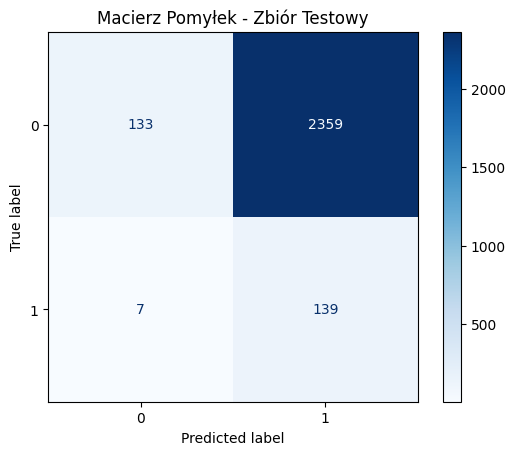

In [29]:
auc_score = roc_auc_score(y_test, prawdopodobienstwo_bankructwa)
print(f"ROC AUC Score: {round(auc_score, 4)}\n")


y_test_pred = (prawdopodobienstwo_bankructwa >= 0.5).astype(int)



print(classification_report(y_test, y_test_pred))


ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, cmap='Blues')
plt.title("Macierz Pomyłek - Zbiór Testowy")
plt.show()

In [30]:
y_train_proba = model.predict_proba(X_train)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, y_train_proba)

In [31]:
target_recall = 0.97 
idx = np.where(recalls[:-1] >= target_recall)[0][-1]
optimal_threshold = thresholds[idx]

In [32]:
print(round(optimal_threshold,6))

9.6e-05


In [33]:
y_test_pred_opt = (prawdopodobienstwo_bankructwa >= optimal_threshold).astype(int)

In [34]:
a_s = accuracy_score(y_test, y_test_pred_opt)
p_s = precision_score(y_test, y_test_pred_opt)
r_s = recall_score(y_test, y_test_pred_opt)
f1_s = f1_score(y_test, y_test_pred_opt)

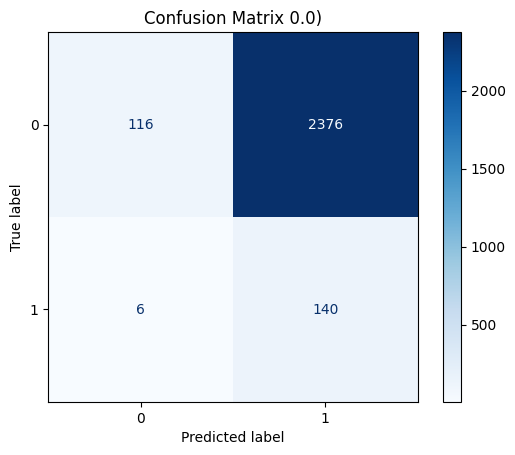

In [35]:
cm = confusion_matrix(y_test, y_test_pred_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix {round(optimal_threshold, 2)})")
plt.show()

In [36]:
print(f"Accuracy: {round(a_s, 4)}")
print(f"Precision: {round(p_s, 4)}")
print(f"Recall: {round(r_s, 4)}")
print(f"F1: {round(f1_s, 4)}")


Accuracy: 0.097
Precision: 0.0556
Recall: 0.9589
F1: 0.1052


# Finalne wyniki

In [37]:
final_proba = model.predict_proba(X_final_test_scaled)[:, 1]
final_pred = (final_proba >= optimal_threshold).astype(int)

/Users/mikolajkoszewski/Library/Mobile Documents/com~apple~CloudDocs/Studia/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [38]:
reverse_mapping = {0: "b'0'", 1: "b'1'"}
final_classes = pd.Series(final_pred).map(reverse_mapping)

In [39]:
df_submission = pd.DataFrame({'class': final_classes})

In [40]:
df_submission.to_csv('b.csv', index=False)